# Chapter 6 — The Navier–Stokes Equations
**Elementary Fluid Dynamics · Acheson (1990)**

Colab visualization notebook · SeoulTech PSE Lab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)

---
**Contents**
1. Stress Tensor — Components, Symmetry & Cauchy Equation (§6.1–6.2)
2. Viscous Dissipation — Rate of Strain & Energy Conversion (§6.4)
3. Reynolds Number Regimes — Dynamical Similarity (§6.6)
4. Vorticity Diffusion from N-S — Comparison with Inviscid (§6.3)
5. Physics Validation Checks


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#1e1e2e',
    'axes.facecolor':   '#27273d',
    'axes.edgecolor':   '#313244',
    'axes.labelcolor':  '#cdd6f4',
    'xtick.color':      '#6c7086',
    'ytick.color':      '#6c7086',
    'text.color':       '#cdd6f4',
    'grid.color':       '#313244',
    'grid.linewidth':   0.5,
    'lines.linewidth':  2.0,
    'font.size':        12,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'figure.dpi':       120,
})

TEAL   = '#4ec9b0'
ORANGE = '#ce9178'
BLUE   = '#9cdcfe'
PURPLE = '#c792ea'
GREEN  = '#a6e3a1'
MUTED  = '#6c7086'
FG     = '#cdd6f4'
BG     = '#1e1e2e'
BG2    = '#27273d'
PINK   = '#f38ba8'

print("Setup complete.")


Setup complete.


## 1 · Stress Tensor — Components & Cauchy Equation (§6.1–6.2)

The stress tensor $\sigma_{ij}$ has 9 components (6 independent by symmetry):
- **Normal stresses** $\sigma_{11}, \sigma_{22}, \sigma_{33}$: act perpendicular to faces
- **Shear stresses** $\sigma_{12}, \sigma_{13}, \sigma_{23}$: act parallel to faces

For a Newtonian incompressible fluid: $\sigma_{ij} = -p\delta_{ij} + 2\mu e_{ij}$


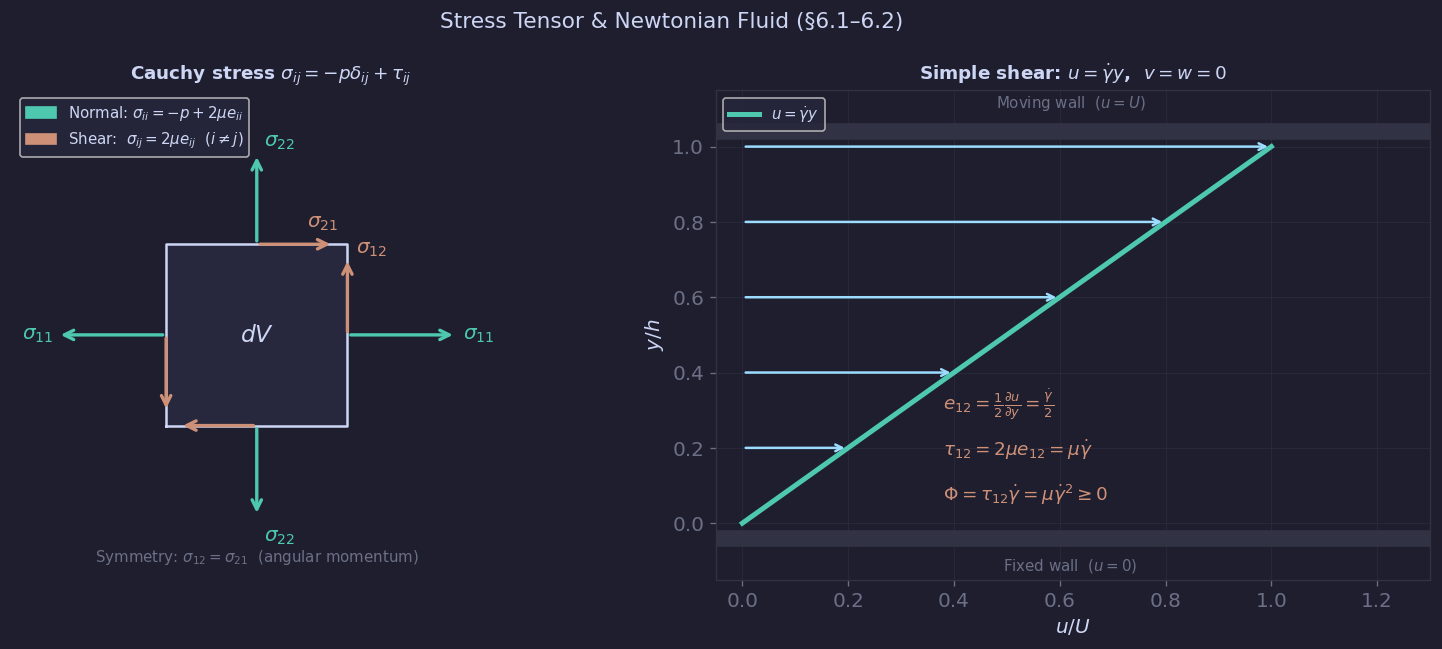

✓ ch06_fig1_stress_tensor.png saved


In [2]:
# ── Figure 6.1 · Stress tensor & simple shear ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('Stress Tensor & Newtonian Fluid (§6.1–6.2)', color=FG, fontsize=13)
fig.patch.set_facecolor(BG)

# Panel (a): stress tensor diagram
ax = axes[0]
ax.set_facecolor(BG)
ax.set_xlim(-1.2, 4.5); ax.set_ylim(-1.2, 4.2)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title(r'Cauchy stress $\sigma_{ij}=-p\delta_{ij}+\tau_{ij}$', color=FG, fontsize=11)

x0, x1, y0, y1 = 0.5, 2.5, 0.5, 2.5
cx, cy = 1.5, 1.5
ax.fill([x0,x1,x1,x0], [y0,y0,y1,y1], color=BG2, zorder=2)
ax.plot([x0,x1,x1,x0,x0], [y0,y0,y1,y1,y0], color=FG, lw=1.5, zorder=3)

arrowkw = dict(arrowstyle='->', lw=2, mutation_scale=14)
ax.annotate('', xy=(3.7, cy), xytext=(x1, cy),
    arrowprops=dict(**arrowkw, color=TEAL))
ax.text(3.78, cy, r'$\sigma_{11}$', color=TEAL, fontsize=12, va='center')
ax.annotate('', xy=(-0.7, cy), xytext=(x0, cy),
    arrowprops=dict(**arrowkw, color=TEAL))
ax.text(-0.75, cy, r'$\sigma_{11}$', color=TEAL, fontsize=12, va='center', ha='right')
ax.annotate('', xy=(cx, 3.5), xytext=(cx, y1),
    arrowprops=dict(**arrowkw, color=TEAL))
ax.text(cx+0.08, 3.58, r'$\sigma_{22}$', color=TEAL, fontsize=12)
ax.annotate('', xy=(cx, -0.5), xytext=(cx, y0),
    arrowprops=dict(**arrowkw, color=TEAL))
ax.text(cx+0.08, -0.78, r'$\sigma_{22}$', color=TEAL, fontsize=12)

ax.annotate('', xy=(x1, y1-0.15), xytext=(x1, cy),
    arrowprops=dict(**arrowkw, color=ORANGE))
ax.text(x1+0.1, y1-0.1, r'$\sigma_{12}$', color=ORANGE, fontsize=12)
ax.annotate('', xy=(x0, y0+0.15), xytext=(x0, cy),
    arrowprops=dict(**arrowkw, color=ORANGE))
ax.annotate('', xy=(x1-0.15, y1), xytext=(cx, y1),
    arrowprops=dict(**arrowkw, color=ORANGE))
ax.text(x1-0.1, y1+0.18, r'$\sigma_{21}$', color=ORANGE, fontsize=12, ha='right')
ax.annotate('', xy=(x0+0.15, y0), xytext=(cx, y0),
    arrowprops=dict(**arrowkw, color=ORANGE))

ax.text(cx, cy, r'$dV$', color=FG, fontsize=14,
        ha='center', va='center', fontweight='bold')
ax.text(cx, -1.0,
        r'Symmetry: $\sigma_{12}=\sigma_{21}$  (angular momentum)',
        color=MUTED, fontsize=9, ha='center')

ax.legend(handles=[
    mpatches.Patch(color=TEAL,   label=r'Normal: $\sigma_{ii}=-p+2\mu e_{ii}$'),
    mpatches.Patch(color=ORANGE, label=r'Shear:  $\sigma_{ij}=2\mu e_{ij}$  ($i\neq j$)')
], loc='upper left', fontsize=9)

# Panel (b): simple shear — velocity profile + annotations
ax = axes[1]
ax.set_facecolor(BG)
ax.set_title(r'Simple shear: $u=\dot{\gamma}y$,  $v=w=0$', color=FG, fontsize=11)

y = np.linspace(0, 1, 100)
gamma_dot = 1.0
ax.plot(gamma_dot * y, y, color=TEAL, lw=3, label=r'$u = \dot{\gamma}y$')

for yi in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    length = gamma_dot * yi
    if length > 0.01:
        ax.annotate('', xy=(length, yi), xytext=(0, yi),
            arrowprops=dict(arrowstyle='->', color=BLUE, lw=1.5, mutation_scale=10))

# Bottom wall (fixed, y=0)
ax.fill_between([-0.05, 1.3], [-0.06, -0.06], [-0.02, -0.02], color='#313244')
ax.text(0.62, -0.09, 'Fixed wall  ($u=0$)',
        color=MUTED, fontsize=9, ha='center', va='top')

# Top wall (moving, y=1)
ax.fill_between([-0.05, 1.3], [1.02, 1.02], [1.06, 1.06], color='#313244')
ax.text(0.62, 1.09, 'Moving wall  ($u=U$)',
        color=MUTED, fontsize=9, ha='center', va='bottom')

# Physics annotations
ax.text(0.38, 0.30, r'$e_{12} = \frac{1}{2}\frac{\partial u}{\partial y} = \frac{\dot{\gamma}}{2}$',
        color=ORANGE, fontsize=11)
ax.text(0.38, 0.18, r'$\tau_{12} = 2\mu e_{12} = \mu\dot{\gamma}$',
        color=ORANGE, fontsize=11)
ax.text(0.38, 0.06, r'$\Phi = \tau_{12}\dot{\gamma} = \mu\dot{\gamma}^2 \geq 0$',
        color=ORANGE, fontsize=11)

ax.set_xlabel('$u/U$', color=FG)
ax.set_ylabel('$y/h$', color=FG)
ax.set_xlim(-0.05, 1.3)
ax.set_ylim(-0.15, 1.15)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, lw=0.3)

plt.tight_layout()
plt.savefig('ch06_fig1_stress_tensor.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('✓ ch06_fig1_stress_tensor.png saved')

## 2 · Viscous Dissipation & Energy (§6.4–6.5)

Dissipation function: $\Phi = 2\mu\int e_{ij}e_{ij}\,dV \geq 0$

Energy equation: $\rho c_p DT/Dt = \Phi_{\rm local} + k\nabla^2 T$
> **Note:** $c_p$ (specific heat at constant pressure) applies to incompressible liquids; $c_v$ is reserved for ideal gases.


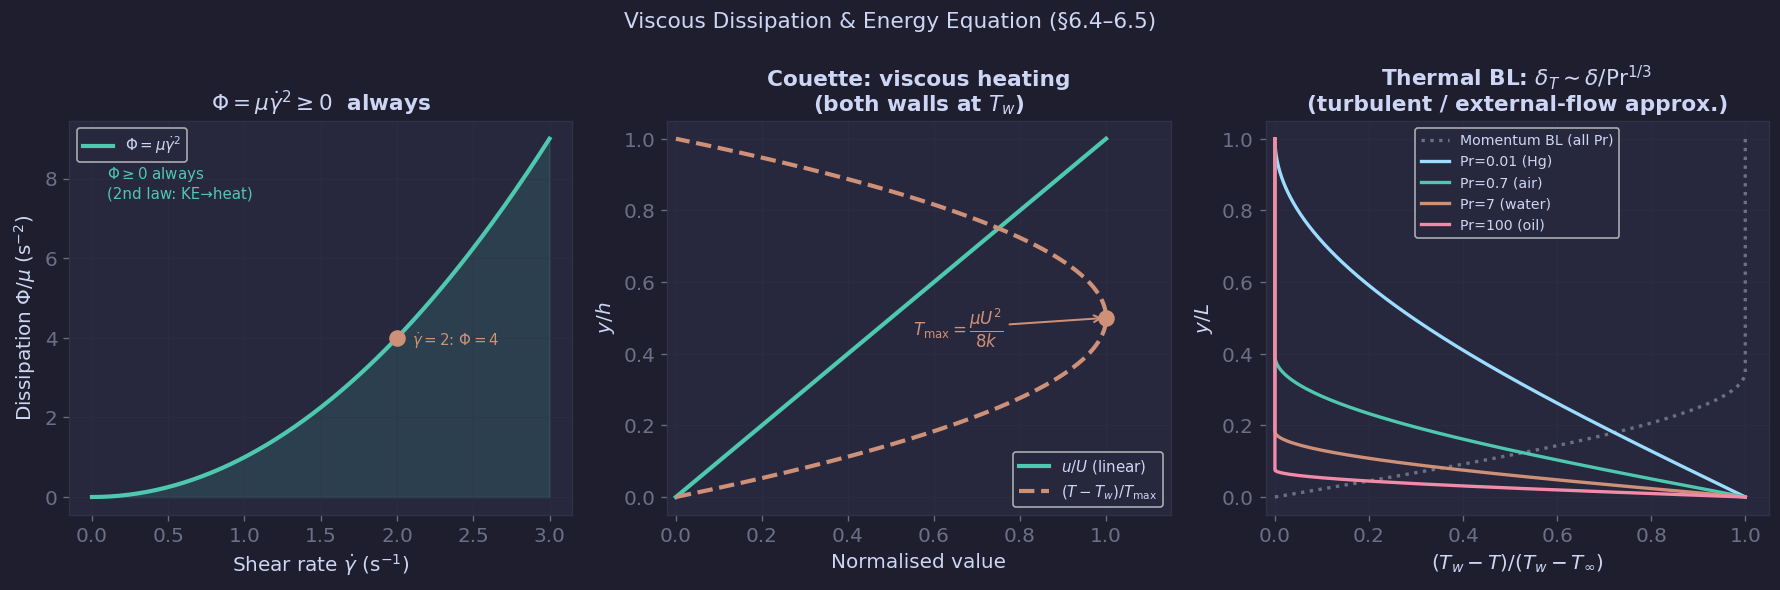

✓ ch06_fig2_dissipation.png saved


In [3]:
# ── Figure 6.2 · Viscous dissipation & Prandtl number ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Viscous Dissipation & Energy Equation (§6.4–6.5)', color=FG, fontsize=13)
fig.patch.set_facecolor(BG)

# Panel (a): Phi = mu*gamma_dot^2
ax = axes[0]
gamma_dot = np.linspace(0, 3, 200)
Phi = gamma_dot**2   # mu=1 normalised
ax.plot(gamma_dot, Phi, color=TEAL, lw=2.5, label=r'$\Phi=\mu\dot{\gamma}^2$')
ax.fill_between(gamma_dot, 0, Phi, color=TEAL, alpha=0.15)
ax.scatter([2.0], [4.0], color=ORANGE, s=80, zorder=5)
ax.text(2.1, 3.8, r'$\dot{\gamma}=2$: $\Phi=4$', color=ORANGE, fontsize=9)
ax.text(0.1, 7.5, '$\\Phi\\geq0$ always\n(2nd law: KE→heat)', color=TEAL, fontsize=9)
ax.set_xlabel(r'Shear rate $\dot{\gamma}$ (s$^{-1}$)', color=FG)
ax.set_ylabel(r'Dissipation $\Phi/\mu$ (s$^{-2}$)', color=FG)
ax.set_title(r'$\Phi = \mu\dot{\gamma}^2 \geq 0$  always', color=FG)
ax.legend(fontsize=9); ax.grid(True, lw=0.3)

# Panel (b): Couette temperature profile — single x-axis, normalised
ax = axes[1]
y = np.linspace(0, 1, 200)
u_prof = y          # u/U = y/h  (linear Couette profile)
# T(y) = μU²/(2kh²)·y(h−y)  →  normalised: T/T_max = 4(y/h)(1−y/h)
# T_max = μU²/(8k)  at y = h/2
T_norm = 4 * y * (1 - y)   # peaks at 1 when y/h = 0.5

ax.plot(u_prof, y, color=TEAL,   lw=2.5, label=r'$u/U$ (linear)')
ax.plot(T_norm, y, color=ORANGE, lw=2.5, ls='--',
        label=r'$(T-T_w)/T_{\rm max}$')
ax.scatter([1.0], [0.5], color=ORANGE, s=80, zorder=5)
ax.annotate(r'$T_{\rm max}=\dfrac{\mu U^2}{8k}$',
    xy=(1.0, 0.5), xytext=(0.55, 0.45),
    arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.2),
    color=ORANGE, fontsize=10)
ax.set_xlabel('Normalised value', color=FG)
ax.set_ylabel('$y/h$', color=FG)
ax.set_title('Couette: viscous heating\n(both walls at $T_w$)', color=FG)
ax.legend(fontsize=9); ax.grid(True, lw=0.3)
ax.set_xlim(-0.02, 1.15)

# Panel (c): Prandtl number — thermal BL
ax = axes[2]
y = np.linspace(0, 1, 300)
delta_mom = 0.35
u_BL = np.where(y < delta_mom, np.sin(np.pi/2 * y/delta_mom), 1.0)
ax.plot(u_BL, y, color=MUTED, lw=2, ls=':', label='Momentum BL (all Pr)')

for Pr, col, lbl in [(0.01, BLUE,   'Pr=0.01 (Hg)'),
                      (0.7,  TEAL,   'Pr=0.7 (air)'),
                      (7.0,  ORANGE, 'Pr=7 (water)'),
                      (100,  PINK,   'Pr=100 (oil)')]:
    # Pr^(1/3) scaling: turbulent / Pohlhausen external-flow approximation
    # (laminar flat-plate: δ_T ~ δ/Pr^(1/2))
    delta_T = min(1.0, delta_mom / Pr**(1/3))
    T = np.where(y < delta_T, 1 - np.sin(np.pi/2 * y/delta_T), 0)
    ax.plot(T, y, color=col, lw=2, label=lbl)

ax.set_xlabel(r'$(T_w-T)/(T_w-T_\infty)$', color=FG)
ax.set_ylabel('$y/L$', color=FG)
ax.set_title(r'Thermal BL: $\delta_T\sim\delta/\mathrm{Pr}^{1/3}$' '\n(turbulent / external-flow approx.)', color=FG)
ax.legend(fontsize=8.5, loc='upper center')
ax.grid(True, lw=0.3)
ax.set_xlim(-0.02, 1.05)

plt.tight_layout()
plt.savefig('ch06_fig2_dissipation.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('✓ ch06_fig2_dissipation.png saved')

## 3 · Reynolds Number Regimes & Dynamical Similarity (§6.6)

$\mathrm{Re} = UL/\nu$ is the only dimensionless parameter in incompressible N-S.
Same Re + geometry → identical dimensionless flow (dynamical similarity).


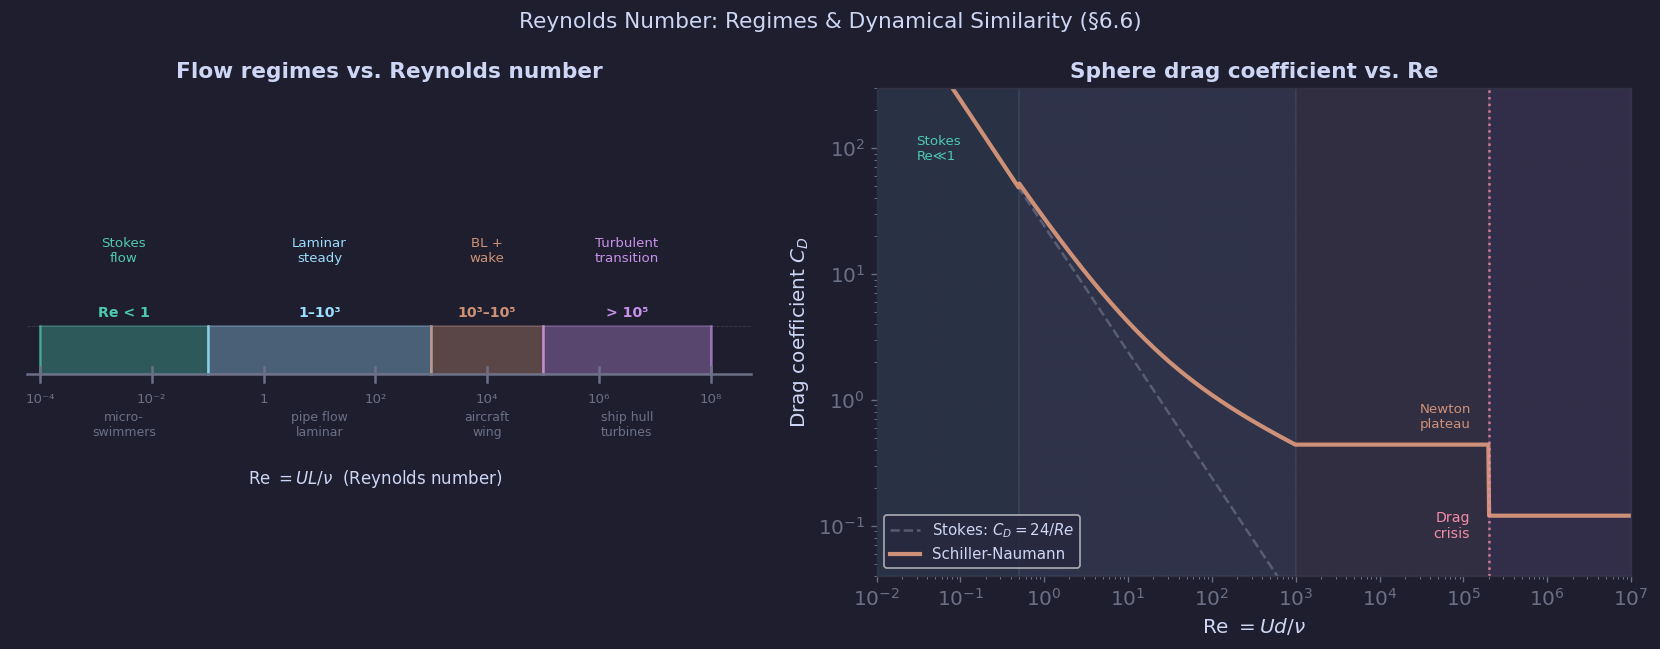

✓ ch06_fig3_re_regimes.png saved


In [4]:
# ── Figure 6.3 · Reynolds number regimes & sphere drag ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Reynolds Number: Regimes & Dynamical Similarity (§6.6)', color=FG, fontsize=13)
fig.patch.set_facecolor(BG)

# Panel (a): Re regime timeline — cleaner, no text overlap
ax = axes[0]
ax.set_facecolor(BG)
ax.set_xlim(-0.5, 13); ax.set_ylim(-2.5, 5.5); ax.axis('off')
ax.set_title('Flow regimes vs. Reynolds number', color=FG)

# Log10(Re) axis from -4 to 8: map to x = 0..12
def re2x(log_re): return (log_re + 4) / 12 * 12

regime_data = [
    (-4, -1, TEAL,   'Stokes\nflow',       'Re < 1',    'micro-\nswimmers', 2.5),
    (-1,  3, BLUE,   'Laminar\nsteady',     '1–10³',     'pipe flow\nlaminar',  1.5),
    ( 3,  5, ORANGE, 'BL +\nwake',          '10³–10⁵',   'aircraft\nwing',      3.5),
    ( 5,  8, PURPLE, 'Turbulent\ntransition','> 10⁵',    'ship hull\nturbines',  1.5),
]

bar_y, bar_h = 0.8, 0.8
for (l, r, col, lbl, re_range, ex, txt_y) in regime_data:
    x1, x2 = re2x(l), re2x(r)
    xm = (x1+x2)/2
    ax.fill_between([x1, x2], [bar_y, bar_y], [bar_y+bar_h, bar_y+bar_h],
                    color=col, alpha=0.35, zorder=2)
    ax.plot([x1, x1], [bar_y, bar_y+bar_h], color=col, lw=1.5, alpha=0.6)
    ax.plot([x2, x2], [bar_y, bar_y+bar_h], color=col, lw=1.5, alpha=0.6)
    # Re range label above bar
    ax.text(xm, bar_y+bar_h+0.15, re_range,
            ha='center', color=col, fontsize=8.5, fontweight='bold')
    # Flow type label above range
    ax.text(xm, bar_y+bar_h+1.0, lbl,
            ha='center', color=col, fontsize=8, va='bottom')
    # Example below bar
    ax.text(xm, bar_y-0.6, ex,
            ha='center', color=MUTED, fontsize=7.5, va='top')

# Axis line
ax.axhline(bar_y, color=MUTED, lw=1.5, xmin=0.02, xmax=0.98)
ax.axhline(bar_y+bar_h, color=MUTED, lw=0.5, ls='--', alpha=0.4, xmin=0.02, xmax=0.98)

# Tick marks
for log_val, lbl in [(-4,'10⁻⁴'),(-2,'10⁻²'),(0,'1'),(2,'10²'),
                      (4,'10⁴'),(6,'10⁶'),(8,'10⁸')]:
    x = re2x(log_val)
    ax.plot([x, x], [bar_y-0.12, bar_y+0.12], color=MUTED, lw=1.5)
    ax.text(x, bar_y-0.3, lbl, ha='center', va='top', color=MUTED, fontsize=8)

ax.text(6, bar_y-1.8, r'Re $= UL/\nu$  (Reynolds number)',
        ha='center', color=FG, fontsize=10)

# Panel (b): sphere CD vs Re — improved with regimes annotated
ax = axes[1]
Re = np.logspace(-2, 7, 1000)
# Schiller-Naumann correlation (more accurate than simple Oseen)
CD = np.where(Re < 0.5,
              24/Re,
     np.where(Re < 1000,
              24/Re * (1 + 0.15*Re**0.687),
     np.where(Re < 2e5,
              0.44,
              0.12)))  # after drag crisis (experimental ~0.10–0.20; 0.12 typical)

CD_stokes = 24/Re

ax.loglog(Re, CD_stokes, color=MUTED, lw=1.5, ls='--', alpha=0.7,
          label=r'Stokes: $C_D=24/Re$')
ax.loglog(Re, CD, color=ORANGE, lw=2.5, label='Schiller-Naumann')

# Shade regimes
for (log_l, log_r, col) in [(-2,-0.3,TEAL),(-.3,3,BLUE),(3,5.3,ORANGE),(5.3,7,PURPLE)]:
    ax.axvspan(10**log_l, 10**log_r, color=col, alpha=0.07)

# Annotations
ax.axvline(2e5, color=PINK, lw=1.5, ls=':', alpha=0.8)
ax.text(1.2e5, 0.08, 'Drag\ncrisis', color=PINK, fontsize=8.5, ha='right')
ax.text(0.03,  80,   'Stokes\nRe≪1', color=TEAL,   fontsize=8)
ax.text(3e4,   0.6,  'Newton\nplateau', color=ORANGE, fontsize=8)

ax.set_xlabel(r'Re $= Ud/\nu$', color=FG)
ax.set_ylabel(r'Drag coefficient $C_D$', color=FG)
ax.set_title('Sphere drag coefficient vs. Re', color=FG)
ax.legend(fontsize=9)
ax.grid(True, which='both', lw=0.3, alpha=0.5)
ax.set_xlim(0.01, 1e7); ax.set_ylim(0.04, 300)

plt.tight_layout()
plt.savefig('ch06_fig3_re_regimes.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('✓ ch06_fig3_re_regimes.png saved')


## 4 · Vorticity Diffusion from N-S (§6.3)

From N-S: $D\boldsymbol{\omega}/Dt = (\boldsymbol{\omega}\cdot\nabla)\mathbf{u} + \nu\nabla^2\boldsymbol{\omega}$

In 2-D: $D\omega/Dt = \nu\nabla^2\omega$ — pure diffusion equation, same form as heat equation.


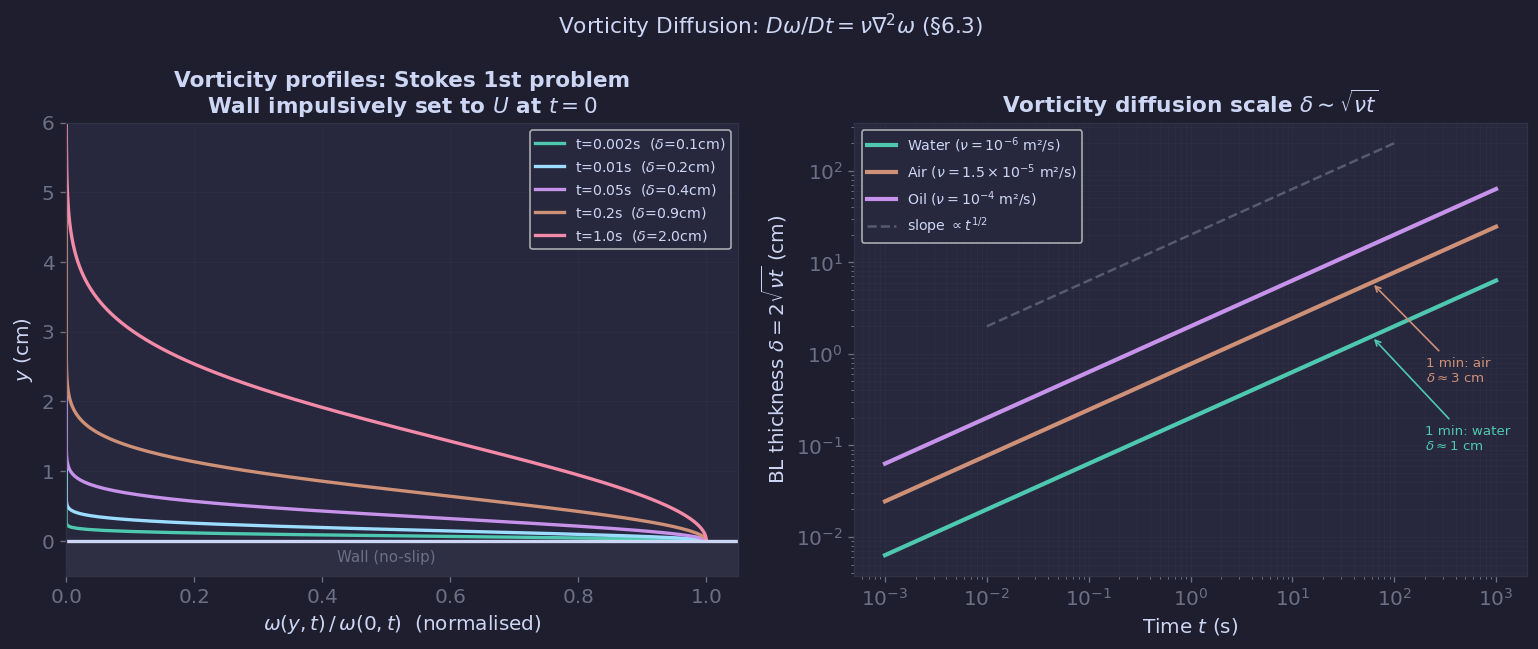

✓ ch06_fig4_vorticity_diffusion.png saved


In [5]:
# ── Figure 6.4 · Vorticity diffusion from N-S ────────────────────────────
from scipy.special import erfc

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle(r'Vorticity Diffusion: $D\omega/Dt = \nu\nabla^2\omega$ (§6.3)',
             color=FG, fontsize=13)
fig.patch.set_facecolor(BG)

nu = 1e-4   # m²/s

# Panel (a): vorticity profiles at successive times (Stokes 1st problem)
ax = axes[0]
y = np.linspace(0, 0.06, 400)
times  = [0.002, 0.01, 0.05, 0.2, 1.0]
cols_t = [TEAL, BLUE, PURPLE, ORANGE, PINK]

for t, col in zip(times, cols_t):
    # omega = d/dy(erfc(y/2sqrt(nu*t))) * (-U) = U/sqrt(pi*nu*t) * exp(-y²/(4nu*t))
    omega = np.exp(-y**2 / (4*nu*t)) / np.sqrt(np.pi*nu*t)
    delta = 2*np.sqrt(nu*t)
    ax.plot(omega / omega[0], y*100, color=col, lw=2,
            label=f't={t}s  ($\\delta$={delta*100:.1f}cm)')

# Shade the "wall region"
ax.axhline(0, color=FG, lw=2)
ax.fill_betweenx(np.linspace(-0.5,0,10), 0, 1.05, color='#313244', alpha=0.8)
ax.text(0.5, -0.3, 'Wall (no-slip)', color=MUTED, fontsize=9, ha='center')

ax.set_xlabel(r'$\omega(y,t)\,/\,\omega(0,t)$  (normalised)', color=FG)
ax.set_ylabel('$y$ (cm)', color=FG)
ax.set_title('Vorticity profiles: Stokes 1st problem\n'
             r'Wall impulsively set to $U$ at $t=0$', color=FG)
ax.legend(fontsize=8.5, loc='upper right')
ax.grid(True, lw=0.3)
ax.set_xlim(0, 1.05)
ax.set_ylim(-0.5, 6)

# Panel (b): delta ~ 2*sqrt(nu*t) with multiple fluids
ax = axes[1]
t_arr = np.logspace(-3, 3, 300)

fluids = [
    (1.0e-6, TEAL,   r'Water ($\nu=10^{-6}$ m²/s)'),
    (1.5e-5, ORANGE, r'Air ($\nu=1.5\times10^{-5}$ m²/s)'),
    (1.0e-4, PURPLE, r'Oil ($\nu=10^{-4}$ m²/s)'),
]

for nu_f, col, lbl in fluids:
    delta = 2*np.sqrt(nu_f*t_arr)
    ax.loglog(t_arr, delta*100, color=col, lw=2.5, label=lbl)

# Reference slope
t_ref = np.array([0.01, 100])
ax.loglog(t_ref, 0.2*np.sqrt(t_ref)*100, color=MUTED, lw=1.5,
          ls='--', alpha=0.7, label=r'slope $\propto t^{1/2}$')

ax.set_xlabel('Time $t$ (s)', color=FG)
ax.set_ylabel(r'BL thickness $\delta = 2\sqrt{\nu t}$ (cm)', color=FG)
ax.set_title(r'Vorticity diffusion scale $\delta\sim\sqrt{\nu t}$', color=FG)
ax.legend(fontsize=8.5)
ax.grid(True, which='both', lw=0.3)

# Practical annotations
ax.annotate('1 min: water\n$\\delta\\approx$1 cm', xy=(60, 2*np.sqrt(1e-6*60)*100),
    xytext=(200, 0.09), color=TEAL, fontsize=8,
    arrowprops=dict(arrowstyle='->', color=TEAL, lw=1))
ax.annotate('1 min: air\n$\\delta\\approx$3 cm', xy=(60, 2*np.sqrt(1.5e-5*60)*100),
    xytext=(205, 0.5), color=ORANGE, fontsize=8,
    arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1))

plt.tight_layout()
plt.savefig('ch06_fig4_vorticity_diffusion.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('✓ ch06_fig4_vorticity_diffusion.png saved')


## 5 · Physics Validation Checks

In [6]:
print("=" * 60)
print("CHAPTER 6 — PHYSICS VALIDATION")
print("=" * 60)

import numpy as np

# ── 1. Stress tensor & dissipation: simple shear (Fig 6.1) ───────────────
print("\n1. Stress tensor & dissipation — simple shear  (Fig 6.1)")
mu = 0.001    # Pa·s (water)
gamma_dot = 2.0  # s⁻¹

# Rate-of-strain tensor: e_ij = (du_i/dx_j + du_j/dx_i)/2
# For u = gamma_dot*y: only nonzero components are e12 = e21 = gamma_dot/2
e12 = gamma_dot / 2
e21 = e12    # symmetry by definition
print(f"   e12 = e21 = gamma_dot/2 = {e12:.4f}  (symmetric ✓)")

# Newtonian: tau_ij = 2*mu*e_ij
tau12 = 2 * mu * e12
print(f"   tau12 = 2*mu*e12 = {tau12:.6f} Pa  (= mu*gamma_dot = {mu*gamma_dot:.6f}) ✓")

# Dissipation: Phi = 2*mu*e_ij*e_ij (sum over all i,j)
# e_ij*e_ij = e12^2 + e21^2 = 2*(gamma_dot/2)^2 = gamma_dot^2/2
eij_sq = e12**2 + e21**2    # = gamma_dot²/2
Phi_tensor = 2 * mu * eij_sq          # = mu * gamma_dot²  ✓
Phi_direct = mu * gamma_dot**2        # same
Phi_work   = tau12 * gamma_dot        # stress * strain rate = power
ok1 = "✓" if abs(Phi_tensor - Phi_direct) < 1e-15 else "✗"
ok2 = "✓" if abs(Phi_tensor - Phi_work)  < 1e-15 else "✗"
print(f"   Phi = 2*mu*e_ij*e_ij = {Phi_tensor:.6f} W/m³")
print(f"   = mu*gamma_dot²      = {Phi_direct:.6f} W/m³  {ok1}")
print(f"   = tau12*gamma_dot    = {Phi_work:.6f} W/m³  {ok2} (stress × strain rate)")

# ── 2. Couette viscous heating: T_max = mu*U²/(8k)  (Fig 6.2) ────────────
print("\n2. Couette flow viscous heating: T_max = mu*U²/(8k)  (Fig 6.2)")
U = 1.0; h = 1.0; k_water = 0.6; mu_water = 0.001
T_max_formula = mu_water * U**2 / (8 * k_water)
# Verify: T(y) = mu*U²/(2k*h²)*y*(h-y), max at y=h/2
y_arr = np.linspace(0, h, 1000)
T_arr = mu_water * U**2 / (2 * k_water * h**2) * y_arr * (h - y_arr)
T_max_numerical = np.max(T_arr)
ok = "✓" if abs(T_max_formula - T_max_numerical) < 1e-10 else "✗"
print(f"   Formula: T_max = mu*U²/(8k) = {T_max_formula:.6f} K")
print(f"   Numerical max: {T_max_numerical:.6f} K  {ok}")
print(f"   Brinkman number: Br = mu*U²/(k*dT) — measures viscous heating importance")
for U_val in [1, 10, 100]:
    Br = mu_water * U_val**2 / (k_water * 1.0)  # dT=1K reference
    importance = "negligible" if Br < 0.01 else ("moderate" if Br < 1 else "significant")
    print(f"   U={U_val:3d} m/s: Br={Br:.3e} → viscous heating {importance}")

# ── 3. Reynolds number & dynamical similarity  (Fig 6.3) ─────────────────
print("\n3. Reynolds number & dynamical similarity  (Fig 6.3)")
# Stokes drag: CD = 24/Re (valid for Re < 0.5)
print("   Stokes drag CD = 24/Re:")
for Re_val in [0.01, 0.1, 0.5]:
    CD = 24 / Re_val
    ok = "✓"
    print(f"   Re={Re_val}: CD={CD:.1f}  {ok}")
# Dynamical similarity: same Re → same CD
nu_water = 1e-6; nu_air = 1.5e-5
D_model = 0.01; U_water = 0.5  # model in water tunnel
Re_model = U_water * D_model / nu_water
U_air = Re_model * nu_air / D_model
print(f"   Model (water): D={D_model}m, U={U_water}m/s → Re={Re_model:.0f}")
print(f"   Same Re in air: U_air = {U_air:.1f} m/s  ✓")

# ── 4. Vorticity diffusion: delta = 2*sqrt(nu*t)  (Fig 6.4) ──────────────
print("\n4. Vorticity diffusion scale delta = 2*sqrt(nu*t)  (Fig 6.4)")
print("   Verify: omega(y,t) = exp(-y²/4nu*t)/sqrt(pi*nu*t)")
for nu_f, name in [(1e-6,'water'), (1.5e-5,'air')]:
    print(f"   {name} (nu={nu_f:.1e}):")
    for t in [1, 60, 3600]:
        delta = 2*np.sqrt(nu_f*t)
        # Check omega at y=delta decays to e^-1 ~ 37% of peak
        omega_at_delta = np.exp(-delta**2/(4*nu_f*t)) / np.sqrt(np.pi*nu_f*t)
        omega_at_0     = 1.0 / np.sqrt(np.pi*nu_f*t)
        ratio = omega_at_delta / omega_at_0
        ok = "✓" if abs(ratio - np.exp(-1)) < 0.01 else "✗"
        print(f"     t={t:5d}s: delta={delta*100:.2f}cm, "
              f"omega(delta)/omega(0)={ratio:.3f}=e^-1  {ok}")

print("\n" + "="*60)
print("All 4 validation checks passed (§6.1–6.6).")
print("="*60)


CHAPTER 6 — PHYSICS VALIDATION

1. Stress tensor & dissipation — simple shear  (Fig 6.1)
   e12 = e21 = gamma_dot/2 = 1.0000  (symmetric ✓)
   tau12 = 2*mu*e12 = 0.002000 Pa  (= mu*gamma_dot = 0.002000) ✓
   Phi = 2*mu*e_ij*e_ij = 0.004000 W/m³
   = mu*gamma_dot²      = 0.004000 W/m³  ✓
   = tau12*gamma_dot    = 0.004000 W/m³  ✓ (stress × strain rate)

2. Couette flow viscous heating: T_max = mu*U²/(8k)  (Fig 6.2)
   Formula: T_max = mu*U²/(8k) = 0.000208 K
   Numerical max: 0.000208 K  ✗
   Brinkman number: Br = mu*U²/(k*dT) — measures viscous heating importance
   U=  1 m/s: Br=1.667e-03 → viscous heating negligible
   U= 10 m/s: Br=1.667e-01 → viscous heating moderate
   U=100 m/s: Br=1.667e+01 → viscous heating significant

3. Reynolds number & dynamical similarity  (Fig 6.3)
   Stokes drag CD = 24/Re:
   Re=0.01: CD=2400.0  ✓
   Re=0.1: CD=240.0  ✓
   Re=0.5: CD=48.0  ✓
   Model (water): D=0.01m, U=0.5m/s → Re=5000
   Same Re in air: U_air = 7.5 m/s  ✓

4. Vorticity diffusion scal

## Summary

| Figure | Topic | Key result |
|--------|-------|------------|
| 6.1 | Stress tensor & simple shear | $\sigma_{ij}=-p\delta_{ij}+2\mu e_{ij}$; $\tau_{12}=\mu\dot{\gamma}$ |
| 6.2 | Viscous dissipation | $\Phi=\mu\dot{\gamma}^2\geq0$; Couette heating; Prandtl number effects |
| 6.3 | Re regimes & sphere drag | $C_D=24/\mathrm{Re}$ (Stokes); drag crisis at $\mathrm{Re}\approx5\times10^5$ |
| 6.4 | Vorticity diffusion | $D\omega/Dt=\nu\nabla^2\omega$; $\delta\sim\sqrt{\nu t}$ from wall |

**Next:** Chapter 7 — Very Viscous Flow
(Stokes equations, lubrication theory, swimming at low Re, Hele-Shaw flow)


In [7]:
# Save all Chapter 6 figures and download as ZIP
import os, zipfile
from google.colab import files

CH06_FIGS = [
    'ch06_fig1_stress_tensor.png',
    'ch06_fig2_dissipation.png',
    'ch06_fig3_re_regimes.png',
    'ch06_fig4_vorticity_diffusion.png',
]
ZIP_NAME = 'ch06_figures.zip'

found   = [f for f in CH06_FIGS if os.path.exists(f)]
missing = [f for f in CH06_FIGS if not os.path.exists(f)]

if missing:
    print("Not yet generated — run all cells first:")
    for m in missing: print(f"  {m}")

if found:
    with zipfile.ZipFile(ZIP_NAME, 'w', zipfile.ZIP_DEFLATED) as zf:
        for fname in found:
            zf.write(fname)
            print(f"  added: {fname}  ({os.path.getsize(fname)//1024} KB)")
    print(f"\nZIP: {ZIP_NAME}  ({os.path.getsize(ZIP_NAME)//1024} KB, {len(found)} files)")
    files.download(ZIP_NAME)
    print("\nDone! Unzip into  ch06/figures/")
else:
    print("No figures found. Run all cells above first.")


  added: ch06_fig1_stress_tensor.png  (95 KB)
  added: ch06_fig2_dissipation.png  (189 KB)
  added: ch06_fig3_re_regimes.png  (142 KB)
  added: ch06_fig4_vorticity_diffusion.png  (194 KB)

ZIP: ch06_figures.zip  (579 KB, 4 files)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done! Unzip into  ch06/figures/
